In [24]:

# Uncomment to install packages if running on a fresh environment
!pip install xgboost scikit-learn pandas numpy


In [25]:

# === Imports ===
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import os
import glob

# plotting (optional)
import matplotlib.pyplot as plt

# === Relevance function ===
# (original simple relevance: extremes are considered rare)
def relevance(y, low_q=0.1, high_q=0.9):
    low, high = np.quantile(y, [low_q, high_q])
    def phi(val):
        if val <= low or val >= high:
            return 1.0
        return 0.0
    return np.vectorize(phi)(y)


In [26]:

def RA_SMOGN(X, y, relevance_func, t=0.5, o_rate=2, u_rate=0.5, base_model=None, feature_importance=None):
    """
    Residual-Adaptive SMOGN

    X: numpy array (features)
    y: numpy array (targets)
    relevance_func: function to compute phi(y)
    t: threshold for rare relevance
    o_rate: oversampling factor
    u_rate: undersampling fraction
    base_model: regressor to compute residuals
    feature_importance: array of feature weights (same length as X.shape[1])
    """
    if base_model is None:
        base_model = RandomForestRegressor(n_estimators=100, random_state=42)

    # Step 1: rare vs normal
    phi_y = relevance_func(y)
    rare_idx = np.where(phi_y > t)[0]
    norm_idx = np.where(phi_y <= t)[0]

    X_rare, y_rare = X[rare_idx], y[rare_idx]
    X_norm, y_norm = X[norm_idx], y[norm_idx]

    # Step 2: residuals
    base_model.fit(X, y)
    y_pred = base_model.predict(X_rare)
    residuals = y_rare - y_pred

    if feature_importance is None:
        # Use feature importance from base model
        feature_importance = base_model.feature_importances_
    feature_importance = feature_importance / (np.sum(feature_importance) + 1e-9)

    synthetic_X, synthetic_y = [], []

    # Step 3: oversampling rare cases
    for i in range(len(X_rare)):
        for _ in range(o_rate):
            # Adaptive noise
            eps = np.random.uniform(-0.1, 0.1, size=X_rare.shape[1])
            x_new = X_rare[i] + eps * feature_importance

            # Residual-based target
            y_pred_i = base_model.predict(X_rare[i].reshape(1, -1))[0]
            r_star = np.random.choice(residuals)
            y_new = y_pred_i + r_star

            synthetic_X.append(x_new)
            synthetic_y.append(y_new)

    # Step 5: under-sample normals
    n_keep = int(len(X_norm) * u_rate)
    if n_keep > 0:
        sel_idx = np.random.choice(len(X_norm), n_keep, replace=False)
        X_norm_sub, y_norm_sub = X_norm[sel_idx], y_norm[sel_idx]
    else:
        X_norm_sub, y_norm_sub = np.empty((0, X.shape[1])), np.array([])

    # Step 6: combine
    X_final = np.vstack([X_rare, X_norm_sub, np.array(synthetic_X)])
    y_final = np.hstack([y_rare, y_norm_sub, np.array(synthetic_y)])

    return X_final, y_final


In [27]:
# === Load dataset ===
# Read dataset (user may need to adjust path)
df = pd.read_csv('/content/descriptors_with_pIC50.csv')
print('Loaded dataset shape:', df.shape)


Loaded dataset shape: (4965, 1447)


In [28]:

# === Preprocessing ===
# Drop identifier/non-numeric columns if present; adjust column names as needed.
drop_cols = ['Name', 'molecule_chembl_id', 'pIC50']
for c in ['Name','molecule_chembl_id']:
    if c not in df.columns:
        # ignore if missing
        pass

# Ensure target column exists
if 'pIC50' in df.columns:
    y = df['pIC50'].values
    X_df = df.drop(columns=['Name','molecule_chembl_id','pIC50'], errors='ignore')
else:
    # assume last column is target if pIC50 missing
    y = df.iloc[:, -1].values
    X_df = df.drop(df.columns[-1], axis=1)

# Keep numeric columns only
X_df = X_df.select_dtypes(include=[np.number])
# Remove near-constant features (std threshold)
X_df = X_df.loc[:, X_df.std() > 0.01]

# Fill missing values
X_df = X_df.fillna(X_df.mean())

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_df.values)

print('Features shape:', X_scaled.shape, 'Target shape:', y.shape)


Features shape: (4965, 1188) Target shape: (4965,)


In [29]:
import numpy as np

# === Apply RA_SMOGN ===
# Use the relevance function defined above. Adjust t/o_rate/u_rate to taste.

# Filter out non-finite values from y and corresponding rows in X_scaled
finite_mask = np.isfinite(y)
X_filtered = X_scaled[finite_mask]
y_filtered = y[finite_mask]

X_bal, y_bal = RA_SMOGN(X_filtered, y_filtered, relevance_func=lambda arr: relevance(arr, low_q=0.1, high_q=0.9),
                       t=0.5, o_rate=3, u_rate=0.7)
print('Balanced shapes -> X:', X_bal.shape, 'y:', y_bal.shape)

Balanced shapes -> X: (6765, 1188) y: (6765,)


In [33]:
# === Train / Validation / Test split (after RA-SMOGN) ===

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.5, random_state=42
)

print('Train:', X_train.shape)
print('Validation:', X_val.shape)
print('Test:', X_test.shape)

Train: (5412, 1188)
Validation: (676, 1188)
Test: (677, 1188)


In [34]:

# === Models and cross-validation ===
cv = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'RandomForest': (RandomForestRegressor(random_state=42),
                     {'model__n_estimators': [100, 200], 'model__max_depth': [None, 6]}),
    'SVR': (SVR(),
            {'model__kernel': ['rbf'], 'model__C': [1, 10]}),
    'KNN': (KNeighborsRegressor(),
            {'model__n_neighbors': [5, 10]}),
    'XGB': (xgb.XGBRegressor(random_state=42, verbosity=0, objective='reg:squarederror'),
            {'model__n_estimators': [100, 200], 'model__max_depth': [4, 6], 'model__learning_rate': [0.1]})
}

results = []
best_models = {}
for name, (model, params) in models.items():
    pipe = Pipeline([('model', model)])
    grid = GridSearchCV(pipe, param_grid=params, cv=cv, scoring='r2', n_jobs=-1)
    print(f'Fitting {name} ...')
    grid.fit(X_train, y_train)
    best = grid.best_estimator_
    best_models[name] = best
    y_pred = best.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    results.append({'Model': name, 'Best Params': grid.best_params_, 'R2': r2, 'RMSE': rmse, 'MAE': mae})


Fitting RandomForest ...
Fitting SVR ...
Fitting KNN ...
Fitting XGB ...


In [35]:

# === Results ===
import pandas as pd
results_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)
results_df


,Model,Best Params,R2,RMSE,MAE
0,RandomForest,"{'model__max_depth': None, 'model__n_estimator...",0.908429,0.696251,0.500560
1,SVR,"{'model__C': 10, 'model__kernel': 'rbf'}",0.907660,0.699167,0.493116
2,XGB,"{'model__learning_rate': 0.1, 'model__max_dept...",0.905412,0.707628,0.504064
3,KNN,{'model__n_neighbors': 5},0.848349,0.896003,0.603157


In [45]:
# === Final test evaluation for the best validation model ===

top_model_name = val_results_df.iloc[0]['Model']
best_model = best_models[top_model_name]

y_test_pred = best_model.predict(X_test)

test_r2   = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae  = mean_absolute_error(y_test, y_test_pred)

print("Best model (by validation):", top_model_name)
print("Test R2   :", test_r2)
print("Test RMSE :", test_rmse)
print("Test MAE  :", test_mae)

Best model (by validation): XGB
Test R2   : 0.9054120669086521
Test RMSE : 0.7076279660151514
Test MAE  : 0.5040639160249373


In [46]:
# === Validation evaluation (single extra cell) ===

val_results = []

for name, best_model in best_models.items():
    y_val_pred = best_model.predict(X_val)

    r2_val   = r2_score(y_val, y_val_pred)
    rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))
    mae_val  = mean_absolute_error(y_val, y_val_pred)

    val_results.append({
        'Model': name,
        'Val_R2': r2_val,
        'Val_RMSE': rmse_val,
        'Val_MAE': mae_val
    })

val_results_df = pd.DataFrame(val_results).sort_values('Val_R2', ascending=False)
val_results_df

,Model,Val_R2,Val_RMSE,Val_MAE
3,XGB,0.902338,0.711695,0.512204
0,RandomForest,0.896781,0.731664,0.531850
1,SVR,0.888893,0.759107,0.534190
2,KNN,0.809305,0.994492,0.663077


Plotting model: XGB


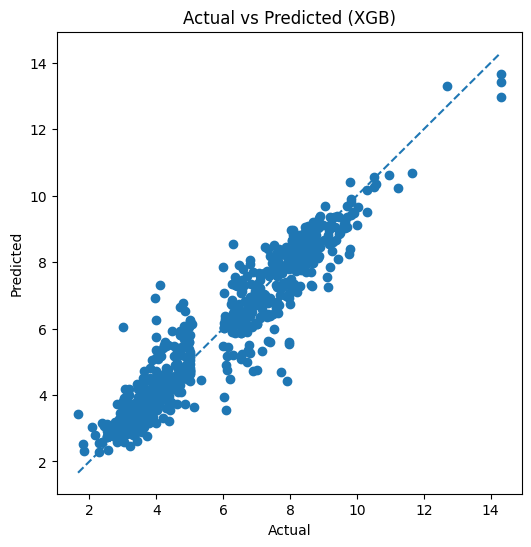

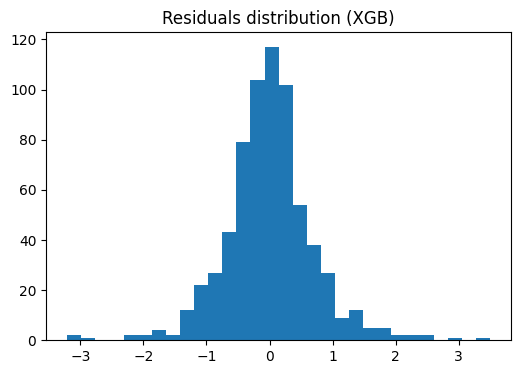

In [47]:
# === Plot predictions for best validation model ===
top_model_name = val_results_df.iloc[0]['Model']
print("Plotting model:", top_model_name)

best_model = best_models[top_model_name]

y_pred = best_model.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title(f'Actual vs Predicted ({top_model_name})')
plt.show()

# Residuals histogram
res = y_test - y_pred

plt.figure(figsize=(6,4))
plt.hist(res, bins=30)
plt.title(f'Residuals distribution ({top_model_name})')
plt.show()